# Festival Sale Planner — The 12 Step Method

**Question:** Should we put this item on sale for this festival?  (Answer: High, Medium or Low)

**Dataset:** `festival_sales.csv` — keep this file in the **same folder** as this notebook.

**Model we will use:** Decision Tree

---

### The 12 Steps

| Step | What we do |
|---|---|
| 0 | Install libraries (only once on a new computer) |
| 1 | Import libraries |
| 2 | Import data |
| 3 | Copy data into a DataFrame |
| 4 | Find nulls, outliers, skew and bias |
| 5 | Scaling the data |
| 6 | Fit and transform |
| 7 | Divide into train and test |
| 8 | Train the model (`model.fit`) |
| 9 | Make predictions (`model.predict`) |
| 10 | Check the model on test data |
| 11 | Test with our own new values |
| 12 | Export the model for the web app |

**Every project follows these same 12 steps.** Only the data and the model change.

Run each cell with **Shift + Enter**.

---
# STEP 0 — Install Libraries

Run this cell **only once** on a new computer. After that you can skip it.

If a library is already installed, Python will simply say *"Requirement already satisfied"* —
that is not an error.

In [57]:
#!pip install pandas
#!pip install numpy
#!pip install matplotlib
#!pip install seaborn
#!pip install scikit-learn
#!pip install joblib
%pip install pandas numpy matplotlib seaborn scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.


**Notes**

- The `!` at the start tells Jupyter to run the command outside Python.
- The library is called **scikit-learn** when installing, but **sklearn** when importing.
- If you are using Anaconda, most of these are already installed.
- After installing, restart the kernel once: menu **Kernel → Restart**.

---
# STEP 1 — Import Libraries

These are the tools we need. We import them once at the top.

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Step 1 done - all libraries imported")

Step 1 done - all libraries imported


---
# STEP 2 — Import Data

We read the CSV file directly from the disk.

The file `festival_sales.csv` must be in the **same folder** as this notebook.

In [59]:
#data = pd.read_csv("festival_sales.csv")
url = "https://raw.githubusercontent.com/bidhan-pokhrel/AI-ML_training/main/festival_sales.csv"
data = pd.read_csv(url)
print("Step 2 done - data imported")
print("Rows and Columns:", data.shape)

Step 2 done - data imported
Rows and Columns: (6000, 9)


If your file is somewhere else, write the full path instead:

```python
data = pd.read_csv("C:/AI_Training/festival_sales.csv")        # Windows
data = pd.read_csv("/home/user/AI_Training/festival_sales.csv")  # Mac / Linux
```

In Windows always use forward slashes `/` in the path.

---
# STEP 3 — Copy Data into a DataFrame

We make a copy and work on the copy.

The original `data` stays safe, so if we make a mistake we can start again without reading
the file.

In [60]:
df = data.copy()

df.head()

,item_code,festival_code,city_code,price,discount_percent,stock_available,advertisement,last_year_units_sold,sale_result
0,2,1,1,1641.0,25,521.0,0,152.0,Medium
1,6,1,1,302.0,20,588.0,1,389.0,High
2,1,1,2,551.0,25,417.0,1,210.0,High
3,2,3,1,2759.0,20,236.0,1,268.0,High
4,3,1,2,642.0,10,95.0,0,36.0,Medium


In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   item_code             6000 non-null   int64  
 1   festival_code         6000 non-null   int64  
 2   city_code             6000 non-null   int64  
 3   price                 5976 non-null   float64
 4   discount_percent      6000 non-null   int64  
 5   stock_available       5982 non-null   float64
 6   advertisement         6000 non-null   int64  
 7   last_year_units_sold  5985 non-null   float64
 8   sale_result           6000 non-null   str    
dtypes: float64(3), int64(5), str(1)
memory usage: 446.8 KB


In [62]:
df.describe().round(2)

,item_code,festival_code,city_code,price,discount_percent,stock_available,advertisement,last_year_units_sold
count,6000.00,6000.00,6000.00,5976.00,6000.00,5982.00,6000.00,5985.00
mean,4.53,2.97,1.39,3599.76,18.25,321.92,0.45,255.19
std,2.30,1.41,0.49,129339.41,14.03,1171.55,0.50,141.62
min,1.00,1.00,1.00,155.00,0.00,20.00,0.00,10.00
25%,3.00,2.00,1.00,1008.00,5.00,166.00,0.00,131.00
50%,5.00,3.00,1.00,1659.50,20.00,306.00,0.00,258.00
75%,7.00,4.00,2.00,2544.50,30.00,451.00,1.00,377.00
max,8.00,5.00,2.00,9999999.00,500.00,90000.00,1.00,499.00


**Columns**

| Column | Meaning |
|---|---|
| item_code | 1 Clothing, 2 Electronics, 3 Sweets & Mithai, 4 Home Decor, 5 Footwear, 6 Groceries, 7 Jewellery, 8 Toys |
| festival_code | 1 Dashain, 2 Tihar, 3 Christmas, 4 Eid, 5 Normal Day |
| city_code | 1 Kathmandu, 2 Pokhara |
| price | price of the item in NPR |
| discount_percent | discount we plan to give (%) |
| stock_available | how many pieces we have in the shop |
| advertisement | 1 if we will advertise it, else 0 |
| last_year_units_sold | units sold in the same festival last year |
| sale_result | **High / Medium / Low — this is our answer (target)** |

---
# STEP 4 — Find Nulls, Outliers, Skew and Bias

## 4.1 Nulls (missing values)

In [63]:
df.isnull().sum()

item_code                0
festival_code            0
city_code                0
price                   24
discount_percent         0
stock_available         18
advertisement            0
last_year_units_sold    15
sale_result              0
dtype: int64

We fill the missing values with the **median** of that column.

We use median (the middle value) because it is not affected by very large wrong values.

In [64]:
df["item_code"] = df["item_code"].fillna(df["item_code"].median())
df["festival_code"] = df["festival_code"].fillna(df["festival_code"].median())
df["city_code"] = df["city_code"].fillna(df["city_code"].median())
df["price"] = df["price"].fillna(df["price"].median())
df["discount_percent"] = df["discount_percent"].fillna(df["discount_percent"].median())
df["stock_available"] = df["stock_available"].fillna(df["stock_available"].median())
df["advertisement"] = df["advertisement"].fillna(df["advertisement"].median())
df["last_year_units_sold"] = df["last_year_units_sold"].fillna(df["last_year_units_sold"].median())

print("Nulls now:", df.isnull().sum().sum())

Nulls now: 0


## 4.2 Outliers

An outlier is a value that is far away from all the others — for example a humidity of 999%
or an age of 200 years.

A **boxplot** shows them. Every dot outside the box is an outlier.

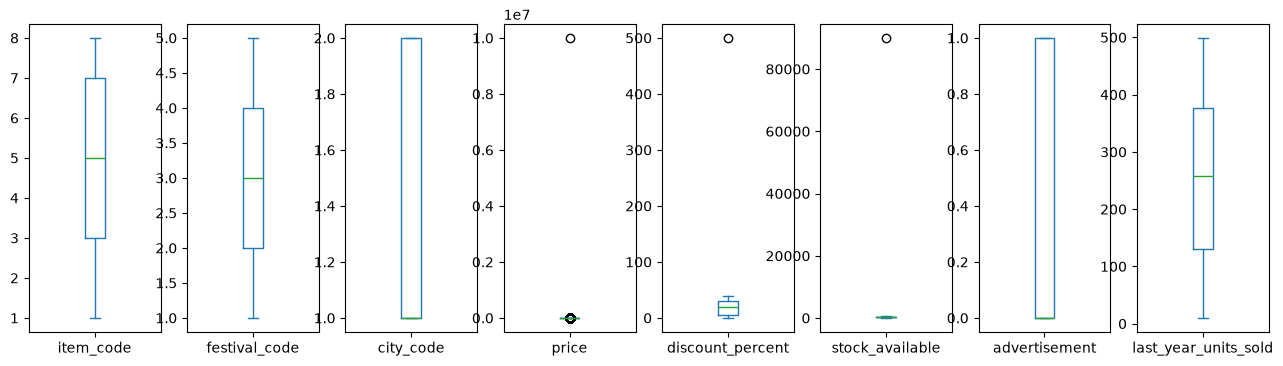

In [65]:
df.plot(kind="box", subplots=True, layout=(1, 8), figsize=(16, 4))
plt.show()

Now we remove the impossible values.

We know the correct range for each column, so we simply keep only the sensible rows.

In [109]:
print("Rows before:", df.shape[0])

df = df[df["price"] <= 100000]
df = df[df["stock_available"] <= 2000]
df = df[df["discount_percent"] <= 100]

print("Rows after :", df.shape[0])

Rows before: 5997
Rows after : 5997


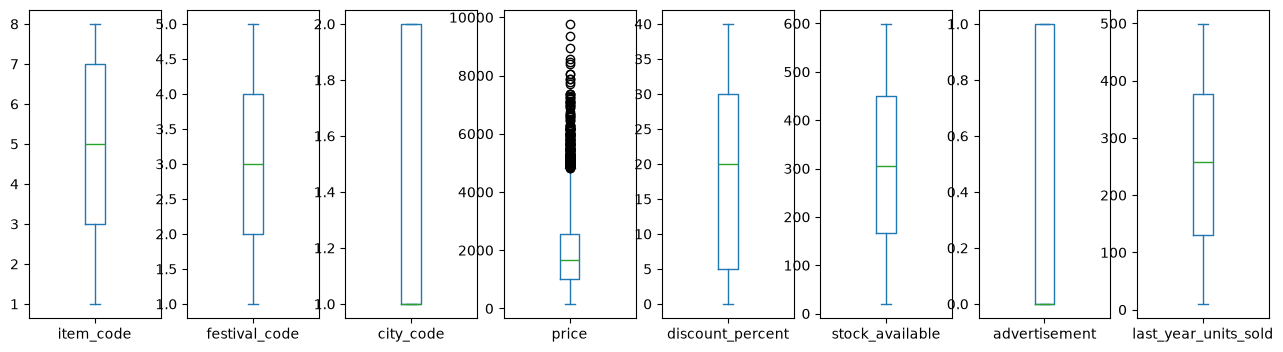

In [67]:
df.plot(kind="box", subplots=True, layout=(1, 8), figsize=(16, 4))
plt.show()

## 4.3 Skew

Skew tells us if the data is balanced or leaning to one side.

| Skew value | Meaning |
|---|---|
| between -0.5 and +0.5 | good, balanced |
| between ±0.5 and ±1 | slightly leaning |
| more than +1 or less than -1 | strongly leaning, should be fixed |

In [68]:
df.skew(numeric_only=True).round(2)

item_code               0.00
festival_code           0.02
city_code               0.47
price                   1.36
discount_percent        0.23
stock_available         0.02
advertisement           0.20
last_year_units_sold   -0.03
dtype: float64

### Now the shape of our own columns

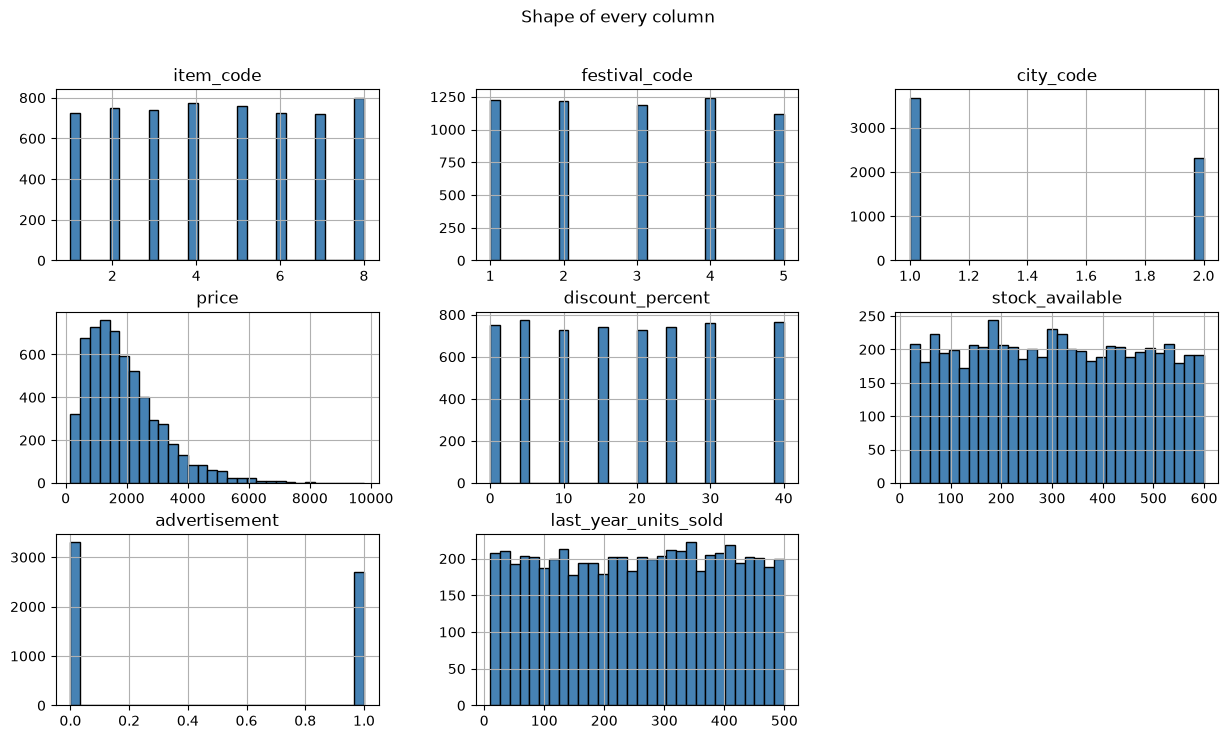

In [69]:
df.hist(figsize=(15, 8), bins=30, color="steelblue", edgecolor="black")
#help(plt.hist)
plt.suptitle("Shape of every column")
plt.show()

### How do we FIX skewed data?

If a column is strongly skewed, we squeeze the long tail using a maths function.
The three common fixes are:

| Fix | Code | Use when |
|---|---|---|
| Log transform | `np.log(df["col"] + 1)` | strong positive skew (money, income, sales) |
| Square root | `np.sqrt(df["col"])` | mild positive skew (counts) |
| Square | `df["col"] ** 2` | negative skew |

We add `+ 1` inside the log because `log(0)` does not exist.

**Log is the most used one.** It pulls very large values closer to the rest, without
changing their order.

Our column **`price`** is strongly skewed, so we fix it now with a log transform.

In [70]:
print("Skew BEFORE fix:", round(df["price"].skew(), 2))

df["price"] = np.log(df["price"] + 1)

print("Skew AFTER fix :", round(df["price"].skew(), 2))

Skew BEFORE fix: 1.36
Skew AFTER fix : -0.4


The shape is now balanced.

**Remember this:** because we changed `price` here, the web app must do exactly the same
thing to any new value before predicting. We will handle that in Step 11.

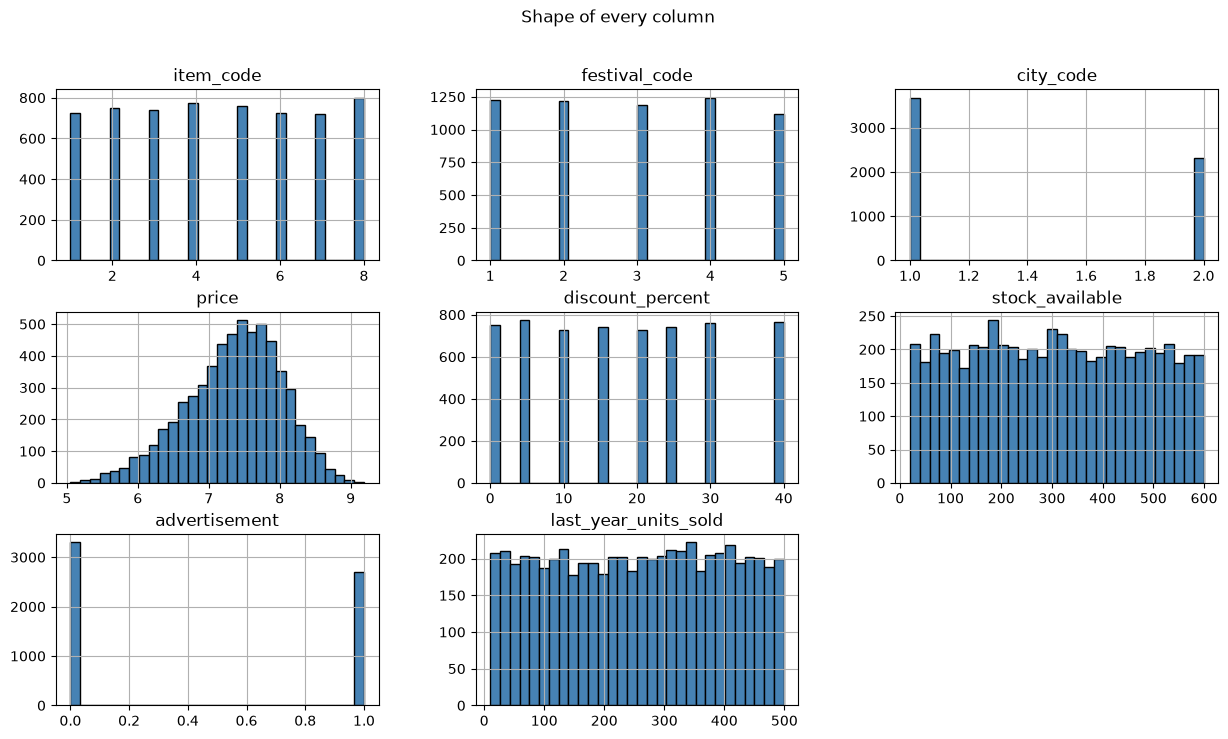

In [102]:
df.hist(figsize=(15, 8), bins=30, color="steelblue", edgecolor="black")
#help(plt.hist)
plt.suptitle("Shape of every column")
plt.show()

## 4.4 Bias in the data

A dataset is **biased** (also called *imbalanced*) when one answer appears far more often
than the other.

This is dangerous. If 95% of rows say No, a lazy model can answer No every single time and
still be 95% "accurate" — while being completely useless.

Let us check our answer column.

In [71]:
print(df["sale_result"].value_counts())
print()
print((df["sale_result"].value_counts(normalize=True) * 100).round(1))

sale_result
Low       2400
Medium    1920
High      1677
Name: count, dtype: int64

sale_result
Low       40.0
Medium    32.0
High      28.0
Name: proportion, dtype: float64


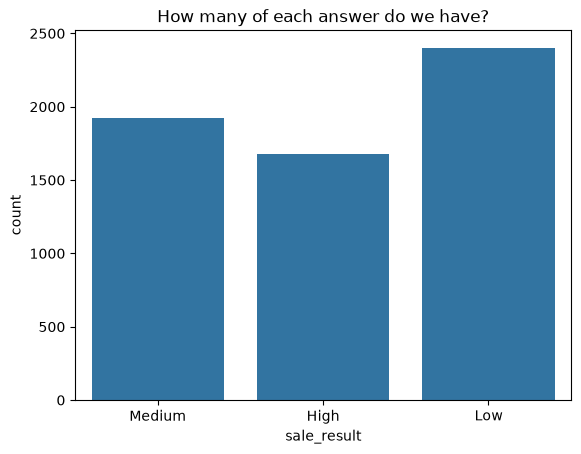

In [72]:
sns.countplot(x="sale_result", data=df)
plt.title("How many of each answer do we have?")
plt.show()

### How do we FIX biased data?

| Fix | How | Note |
|---|---|---|
| Collect more data | get more rows of the rare answer | always the best fix |
| `class_weight="balanced"` | one word inside the model | easiest, we use this |
| Undersampling | delete rows of the common answer | throws away data |

**Our data is reasonably balanced**, so no fix is needed here.

Always run this check anyway — it takes 5 seconds and it saves you from a useless model.

---
# STEP 5 — Scaling the Data

## 5.1 Separate X and y

- **X** = the input columns
- **y** = the answer column

In [74]:
X = df.drop("sale_result", axis=1)
y = df["sale_result"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (5997, 8)
y shape: (5997,)


,item_code,festival_code,city_code,price,discount_percent,stock_available,advertisement,last_year_units_sold
0,2,1,1,7.403670,25,521.0,0,152.0
1,6,1,1,5.713733,20,588.0,1,389.0
2,1,1,2,6.313548,25,417.0,1,210.0
3,2,3,1,7.922986,20,236.0,1,268.0
4,3,1,2,6.466145,10,95.0,0,36.0


## 5.2 Why do we need scaling?

Look at the numbers below. Some columns have very big values and some have very small ones.

The model can think the bigger number is more important, which is wrong.
Scaling brings every column to the same range.

In [75]:
X.describe().round(2)

,item_code,festival_code,city_code,price,discount_percent,stock_available,advertisement,last_year_units_sold
count,5997.00,5997.00,5997.00,5997.00,5997.00,5997.00,5997.00,5997.00
mean,4.53,2.97,1.39,7.36,18.16,306.98,0.45,255.20
std,2.30,1.41,0.49,0.68,12.57,166.13,0.50,141.43
min,1.00,1.00,1.00,5.05,0.00,20.00,0.00,10.00
25%,3.00,2.00,1.00,6.92,5.00,167.00,0.00,131.00
50%,5.00,3.00,1.00,7.41,20.00,306.00,0.00,258.00
75%,7.00,4.00,2.00,7.84,30.00,451.00,1.00,377.00
max,8.00,5.00,2.00,9.19,40.00,599.00,1.00,499.00


## 5.3 Create the scaler

`StandardScaler` changes every column so that its mean becomes 0.

In [76]:
scaler = StandardScaler()

print("Step 5 done - scaler is ready")

Step 5 done - scaler is ready


---
# STEP 6 — Fit and Transform

- **fit** = the scaler looks at the data and learns the mean and the spread
- **transform** = the scaler changes the numbers

`fit_transform` does both together in one line.

In [77]:
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,item_code,festival_code,city_code,price,discount_percent,stock_available,advertisement,last_year_units_sold
0,-1.100840,-1.401163,-0.793486,0.071762,0.543805,1.288364,-0.904336,-0.729753
1,0.641733,-1.401163,-0.793486,-2.427390,0.146049,1.691690,1.105784,0.946180
2,-1.536483,-1.401163,1.260262,-1.540358,0.543805,0.662306,1.105784,-0.319609
3,-1.100840,0.021589,-0.793486,0.839748,0.146049,-0.427277,1.105784,0.090535
4,-0.665197,-1.401163,1.260262,-1.314691,-0.649462,-1.276068,-0.904336,-1.550041


In [78]:
X_scaled.describe().round(2)

,item_code,festival_code,city_code,price,discount_percent,stock_available,advertisement,last_year_units_sold
count,5997.00,5997.00,5997.00,5997.00,5997.00,5997.00,5997.00,5997.00
mean,0.00,0.00,0.00,-0.00,0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.54,-1.40,-0.79,-3.41,-1.44,-1.73,-0.90,-1.73
25%,-0.67,-0.69,-0.79,-0.64,-1.05,-0.84,-0.90,-0.88
50%,0.21,0.02,-0.79,0.09,0.15,-0.01,-0.90,0.02
75%,1.08,0.73,1.26,0.72,0.94,0.87,1.11,0.86
max,1.51,1.44,1.26,2.71,1.74,1.76,1.11,1.72


Look at the `mean` row above — every column is now close to **0**.

The shape of the data did not change, only the scale.

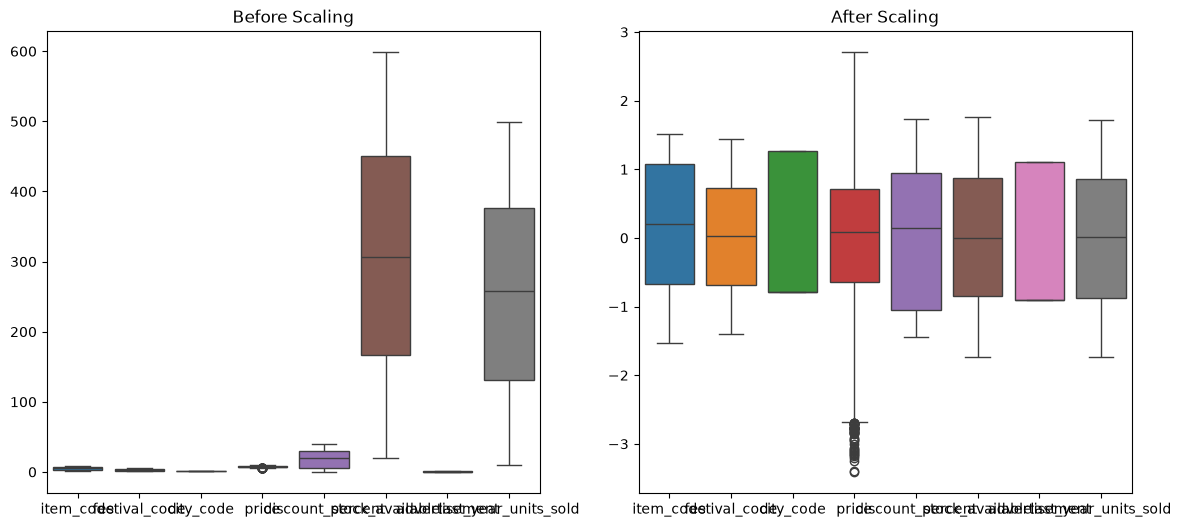

In [107]:
# Set up the figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot before scaling
sns.boxplot(data=X, ax=axes[0])
axes[0].set_title("Before Scaling")

# Boxplot after scaling
sns.boxplot(data=X_scaled, ax=axes[1])
axes[1].set_title("After Scaling")

plt.show()

---
# STEP 7 — Divide into Train and Test

We keep **80% for training** and **hide 20% for testing**.

The model learns from the training part only. The testing part is the exam — the model has
never seen it. This is the only honest way to check a model.

`stratify=y` keeps the same mix of answers in both parts.
`random_state=42` makes everyone in the class get the same split.

In [79]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

print("Training rows:", X_train.shape[0])
print("Testing rows :", X_test.shape[0])

Training rows: 4797
Testing rows : 1200


---
# STEP 8 — Train the Model

This is the actual machine learning. It is **one line**: `model.fit()`

## Why Decision Tree?

**Decision Tree** is the right choice here, and this project shows exactly why.

The pattern in this data is a **combination rule**: Jewellery sells during Dashain,
Home Decor sells during Tihar, Toys sell at Christmas. It is not “more of X means more
sales” — it depends on which item is paired with which festival.

A Decision Tree handles this naturally, because it can ask two questions in a row:

```
Is the festival Tihar?
   |-- Yes -> Is the item Home Decor or Sweets?
   |            |-- Yes -> HIGH
   |            |-- No  -> MEDIUM
   |-- No  -> Is the festival Dashain?
                |-- Yes -> Is the item Jewellery or Clothing?  -> HIGH
```

Try Logistic Regression on this same data and you will get only about 52% accuracy, because
a straight line cannot express “this item WITH that festival”. That is a genuinely useful
thing for students to see.

`max_depth=8` gives the tree enough room for these combinations without memorising the rows.

In [80]:
model = DecisionTreeClassifier(max_depth=8, random_state=42)

model.fit(X_train, y_train)

print("Step 8 done - model is trained")

Step 8 done - model is trained


### Let us actually SEE the tree

This is the biggest advantage of a Decision Tree: we can look inside it and read the rules.

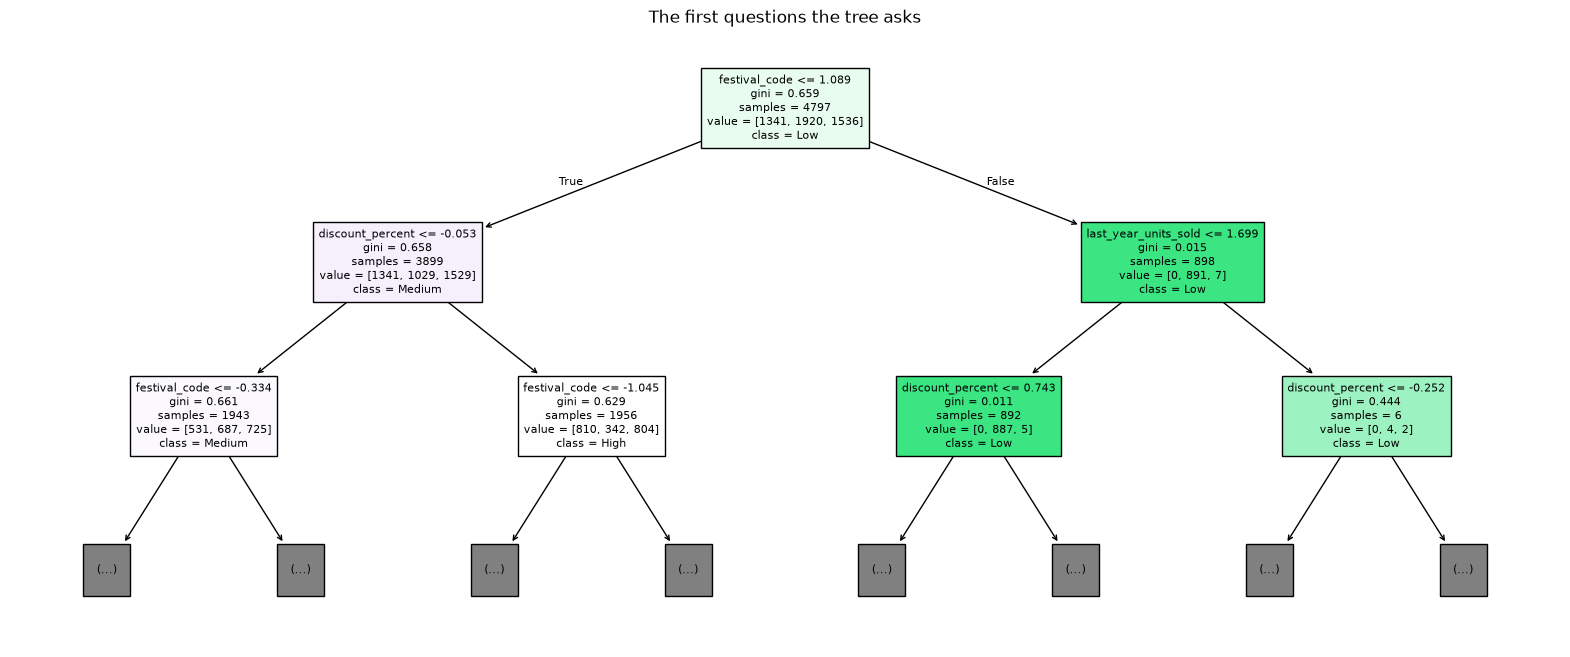

In [81]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 8))
plot_tree(model,
          feature_names=X.columns,
          class_names=model.classes_,
          filled=True,
          fontsize=8,
          max_depth=2)          # show only the first 2 levels, otherwise it is too big
plt.title("The first questions the tree asks")
plt.show()

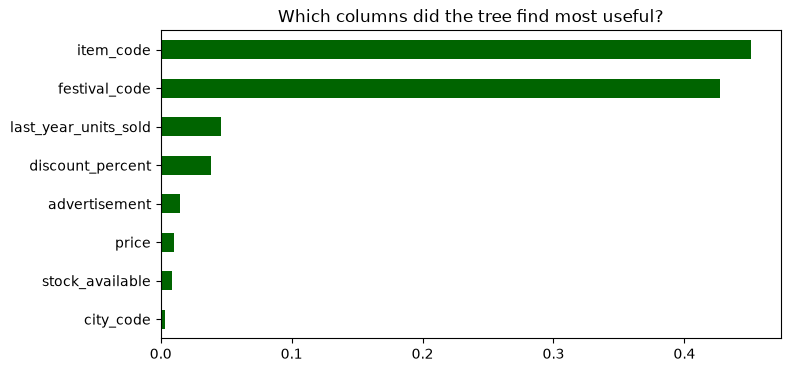

item_code               0.451
festival_code           0.427
last_year_units_sold    0.046
discount_percent        0.038
advertisement           0.015
price                   0.010
stock_available         0.009
city_code               0.004
dtype: float64


In [82]:
importance = pd.Series(model.feature_importances_, index=X.columns)

importance.sort_values().plot(kind="barh", color="darkgreen", figsize=(8, 4))
plt.title("Which columns did the tree find most useful?")
plt.show()

print(importance.sort_values(ascending=False).round(3))

---
# STEP 9 — Make Predictions

Now we give the model the **test data** (which it has never seen) and ask for its answers.

In [83]:
y_pred = model.predict(X_test)

print("First 10 predictions :", list(y_pred[:10]))
print("First 10 real answers:", list(y_test[:10]))

First 10 predictions : ['Medium', 'Medium', 'Medium', 'High', 'Medium', 'Low', 'Low', 'Medium', 'Low', 'Low']
First 10 real answers: ['Medium', 'Low', 'High', 'High', 'High', 'Low', 'Low', 'Medium', 'Low', 'Low']


In [84]:
result = pd.DataFrame({"Real Answer": y_test.values,
                       "Model Prediction": y_pred})

result.head(15)

,Real Answer,Model Prediction
0,Medium,Medium
1,Low,Medium
2,High,Medium
3,High,High
4,High,Medium
5,Low,Low
6,Low,Low
7,Medium,Medium
8,Low,Low
9,Low,Low


---
# STEP 10 — Check the Model

## 10.1 How many did the model get correct?

In [85]:
correct = (y_pred == y_test).sum()
total = len(y_test)

print("Total test rows      :", total)
print("Correctly predicted  :", correct)
print("Wrongly predicted    :", total - correct)

Total test rows      : 1200
Correctly predicted  : 1001
Wrongly predicted    : 199


In [86]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy in percent:", round(accuracy * 100, 2), "%")

Accuracy: 0.8341666666666666
Accuracy in percent: 83.42 %


In [87]:
baseline = df["sale_result"].value_counts(normalize=True).max()

print("If we always answered the most common answer:", round(baseline * 100, 2), "%")
print("Our model                                   :", round(accuracy * 100, 2), "%")
print()
print("Our model must be clearly better than the baseline, otherwise it learned nothing.")

If we always answered the most common answer: 40.02 %
Our model                                   : 83.42 %

Our model must be clearly better than the baseline, otherwise it learned nothing.


## 10.2 Confusion Matrix

This table shows exactly which mistakes the model made.
The numbers on the diagonal are the correct answers.

In [88]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

print(cm)

[[274   0  62]
 [  0 419  61]
 [ 29  47 308]]


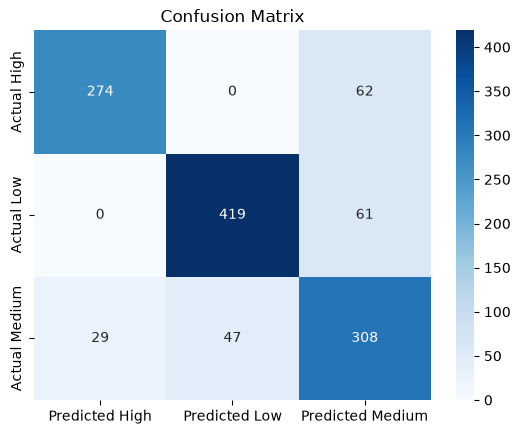

In [89]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted " + c for c in model.classes_],
            yticklabels=["Actual " + c for c in model.classes_])
plt.title("Confusion Matrix")
plt.show()

## 10.3 Full report

In [90]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.90      0.82      0.86       336
         Low       0.90      0.87      0.89       480
      Medium       0.71      0.80      0.76       384

    accuracy                           0.83      1200
   macro avg       0.84      0.83      0.83      1200
weighted avg       0.84      0.83      0.84      1200



| Word | Meaning |
|---|---|
| precision | when the model gave this answer, how often was it right |
| recall | out of all the real cases, how many did the model catch |
| f1-score | balance of precision and recall |
| support | how many rows of that type were in the test data |

## 10.4 Check the training score also

If the training score is very high but the test score is low, the model has **memorised**
the training data instead of learning. That is called **overfitting**.

In [91]:
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print("Training accuracy:", round(train_accuracy * 100, 2), "%")
print("Testing accuracy :", round(test_accuracy * 100, 2), "%")
print("Difference       :", round((train_accuracy - test_accuracy) * 100, 2), "%")

Training accuracy: 86.97 %
Testing accuracy : 83.42 %
Difference       : 3.55 %


A small difference means the model is healthy.

A large difference (more than about 10%) means overfitting — use a simpler model, or a
smaller `max_depth`, or collect more data.

---
# STEP 11 — Test the Model with New Data

Now we give the model values that are **not in the file at all** — values that we type
ourselves.

**Very important:** new data must be prepared in exactly the same way as the training data.

1. Put the values in a DataFrame with the **same column names and same order**
2. Scale it with the **same scaler**
3. Only then call `predict`

Column order: `item_code, festival_code, city_code, price, discount_percent, stock_available, advertisement, last_year_units_sold`

## 11.1 Type your own values

Change the numbers below to anything you like, then run the cell.

In [92]:
new_row = pd.DataFrame([[7, 1, 1, 4500, 20, 300, 1, 350]], columns=X.columns)

new_row

,item_code,festival_code,city_code,price,discount_percent,stock_available,advertisement,last_year_units_sold
0,7,1,1,4500,20,300,1,350


**Do not forget the log transform.**

In Step 4.3 we changed `price` with a log. The model learned from log values, so any new
value must also be converted the same way, otherwise the answer will be completely wrong.

In [93]:
new_row["price"] = np.log(new_row["price"] + 1)

new_row

,item_code,festival_code,city_code,price,discount_percent,stock_available,advertisement,last_year_units_sold
0,7,1,1,8.412055,20,300,1,350


## 11.2 Scale the new data

We use `transform` here, **not** `fit_transform`.

The scaler already learned in Step 6. If we used `fit_transform` here, it would learn again
from one single row and the prediction would be wrong.

In [94]:
new_row_scaled = scaler.transform(new_row)

new_row_scaled = pd.DataFrame(new_row_scaled, columns=X.columns)

new_row_scaled

,item_code,festival_code,city_code,price,discount_percent,stock_available,advertisement,last_year_units_sold
0,1.077376,-1.401163,-0.793486,1.563004,0.146049,-0.04201,1.105784,0.670394


## 11.3 Predict

In [95]:
prediction = model.predict(new_row_scaled)

print("Should we put this item on sale for this festival?", prediction[0])

Should we put this item on sale for this festival? High


## 11.4 How sure is the model?

`predict` gives only the answer. `predict_proba` gives the **chance** behind that answer.

In [96]:
probability = model.predict_proba(new_row_scaled)

chances = pd.DataFrame({"answer": model.classes_,
                        "chance_%": (probability[0] * 100).round(2)})

chances

,answer,chance_%
0,High,100.0
1,Low,0.0
2,Medium,0.0


## 11.5 Try a few different cases at once

In [97]:
many_rows = pd.DataFrame([
    [7, 1, 1, 4500, 20, 300, 1, 350],    # Jewellery in Kathmandu during Dashain
    [4, 2, 1, 900, 25, 400, 1, 300],    # Home Decor during Tihar
    [8, 3, 2, 1200, 20, 250, 1, 220],    # Toys in Pokhara at Christmas
    [3, 4, 1, 600, 15, 350, 1, 280],    # Sweets & Mithai during Eid
    [2, 5, 2, 25000, 0, 100, 0, 60],    # expensive Electronics on a normal day
], columns=X.columns)
many_rows["price"] = np.log(many_rows["price"] + 1)

many_rows_scaled = pd.DataFrame(scaler.transform(many_rows), columns=X.columns)

results = many_rows.copy()
results["prediction"] = model.predict(many_rows_scaled)

results

,item_code,festival_code,city_code,price,discount_percent,stock_available,advertisement,last_year_units_sold,prediction
0,7,1,1,8.412055,20,300,1,350,High
1,4,2,1,6.803505,25,400,1,300,High
2,8,3,2,7.090910,20,250,1,220,High
3,3,4,1,6.398595,15,350,1,280,High
4,2,5,2,10.126671,0,100,0,60,Low


---
# STEP 12 — Export the Model for the Web App

Training took a few seconds here, but on real data it can take hours. We do not want to
train the model again every time someone opens the app.

So we **save the trained model into a file**. This is called **pickling**.

Think of it like cooking: training is the cooking, the `.pkl` file is the meal in the
freezer, and the app just reheats it.

## 12.1 What do we save?

We must save **three** things together, not just the model:

| What | Why |
|---|---|
| the **model** | it makes the prediction |
| the **scaler** | new data must be scaled the same way, or the answer will be wrong |
| the **column names** | so the app sends the columns in the correct order |

In [98]:
import joblib

package = {
    "model": model,
    "scaler": scaler,
    "columns": list(X.columns)
}

joblib.dump(package, "festival_model.pkl")

print("Model saved as festival_model.pkl")

Model saved as festival_model.pkl


## 12.2 Always test the saved file

Never build an app on top of a `.pkl` file you have not tested.

In [99]:
loaded = joblib.load("festival_model.pkl")

loaded_model = loaded["model"]
loaded_scaler = loaded["scaler"]
loaded_columns = loaded["columns"]

print("Columns the model expects:", loaded_columns)

Columns the model expects: ['item_code', 'festival_code', 'city_code', 'price', 'discount_percent', 'stock_available', 'advertisement', 'last_year_units_sold']


In [100]:
test_row = pd.DataFrame([[7, 1, 1, 4500, 20, 300, 1, 350]], columns=loaded_columns)
test_row["price"] = np.log(test_row["price"] + 1)

test_row_scaled = pd.DataFrame(loaded_scaler.transform(test_row), columns=loaded_columns)

print("Prediction from the saved file:", loaded_model.predict(test_row_scaled)[0])

Prediction from the saved file: High


If the answer above is the same as in Step 11.3, the file is correct and ready to use.

## 12.3 Create requirements.txt automatically

When we put the app on the internet, the server is an empty computer. It has no pandas and
no scikit-learn until we tell it what to install. That list goes in **requirements.txt**.

There is one important detail. A `.pkl` file saved by scikit-learn version 1.5 may **refuse
to open** on a server that installed version 1.8. This is the most common reason a working
app fails after hosting.

The safe way is to write down the exact versions of **this** computer, because this is the
computer that created the `.pkl` file.

In [101]:
import sklearn

lines = [
    "streamlit",
    "pandas==" + pd.__version__,
    "numpy==" + np.__version__,
    "scikit-learn==" + sklearn.__version__,
    "joblib==" + joblib.__version__,
]

text = "\n".join(lines)

file = open("requirements.txt", "w")
file.write(text)
file.close()

print("requirements.txt created with these lines:")
print()
print(text)

requirements.txt created with these lines:

streamlit
pandas==3.0.5
numpy==2.4.6
scikit-learn==1.9.0
joblib==1.5.3


## 12.4 What to upload to GitHub

| File | Needed for the app? |
|---|---|
| `festival_app.py` | YES - the app itself |
| `festival_model.pkl` | YES - the trained model |
| `requirements.txt` | YES - the list of libraries |
| `festival_sales.csv` | No - only used for training |
| this notebook | No - but nice to keep |

Upload the **first three** to a **public** GitHub repository, then deploy from
share.streamlit.io with Main file path = `festival_app.py`.

The app does **not** read the CSV file. It only reads the `.pkl` file. That is the whole
point of exporting the model.

---
# Finished

| Step | What we did |
|---|---|
| 0 | Installed the libraries |
| 1 | Imported libraries |
| 2 | Imported the CSV file |
| 3 | Copied it into a DataFrame |
| 4 | Fixed nulls, removed outliers, checked skew and bias |
| 5 | Separated X and y, created the scaler |
| 6 | fit_transform on the data |
| 7 | Split into 80% train and 20% test |
| 8 | Trained the Decision Tree model |
| 9 | Predicted on the test data |
| 10 | Checked how many predictions were correct |
| 11 | Tested with our own new values |
| 12 | Saved `festival_model.pkl` and created requirements.txt |

**Next:** run the web app.

```
streamlit run festival_app.py
```